In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

#variable inputs
ep= 1e-6

rackx = 75 #rack position
racky = 425.4
racky2= racky/2

pivoty = (553+573)/2 #pivot of the upright
pivotx = 0

ackx= 80 #tie rod connector point
ackang = 0*np.pi/180 #33 is what ive found 100% ackerman
acky= ackx * np.tan(ackang)

#print(pivoty +acky)
tie= ((-rackx+ackx)**2 + (-racky2 +acky +pivoty)**2)**(1/2)

dist= 82.55/2 #travel of rack

tieang = np.arctan2(-(-racky2 +acky),(-rackx+ackx))
ack= ((pivotx-ackx)**2 + (acky)**2)**(1/2)

wheelbase= 1550
track = 1200
CGx= .5 #percent away from front
stepPer=.3


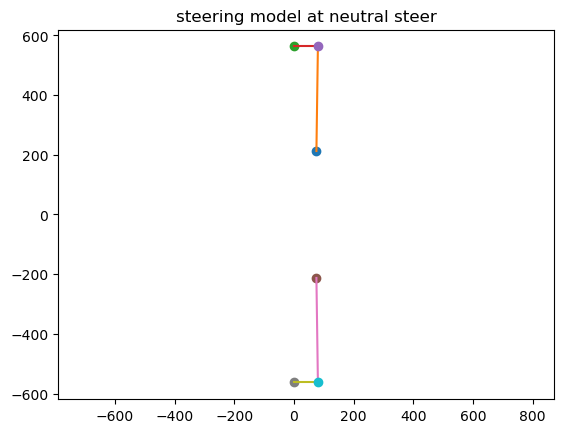

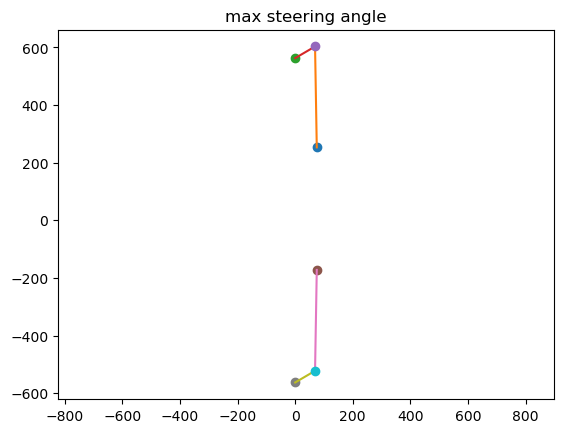

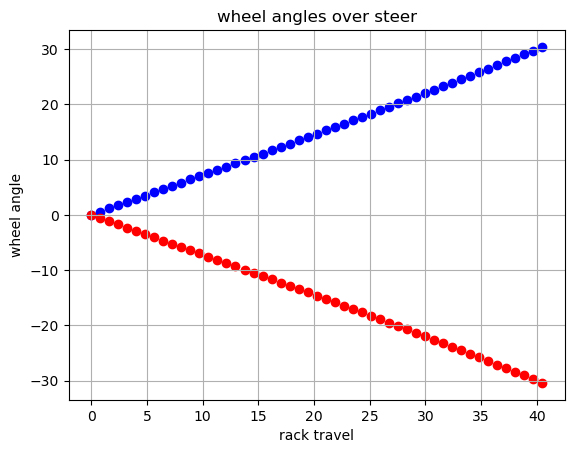

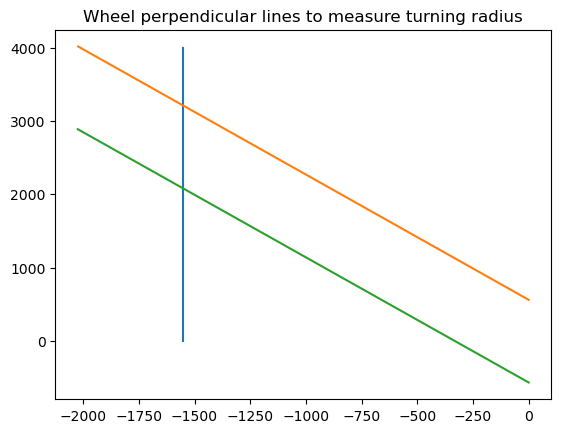

ackerman angle: 0.0
front wheels intersection radius top calculated in x,y [640791.5455053706, -1092814.5597048393]
front wheels intersection radius bottom calculated in x,y [640791.5455053705, -1092814.5597048393]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

#plot 1 is nuetral steer, 
#plot 2 is full steer to the left, 
#plot 3 is the wheel angles, 
#plot 4 isfinding where the tires will intersect

#print(tie, ack)
#print(tieang*180/np.pi,ackang*180/np.pi) 
plt.plot(rackx, racky2, "o")
plt.plot([rackx,pivotx+ackx], [racky2,pivoty +acky], "-")
plt.plot(pivotx, pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [pivoty,pivoty +acky], "-")
plt.plot(pivotx+ackx, pivoty +acky, "o")

plt.plot(rackx, -racky2, "o")
plt.plot([rackx,pivotx+ackx], [-racky2,-pivoty -acky], "-")
plt.plot(pivotx, -pivoty, "o")
plt.plot([pivotx,pivotx+ackx], [-pivoty,-pivoty -acky], "-")
plt.plot(pivotx+ackx, -pivoty -acky, "o")
plt.axis('equal')

plt.title("steering model at neutral steer")
plt.show()

#print(ackang/np.pi*180)
steps=51
MM = np.empty([2,steps])
Tieang= np.empty([2,steps])
ang = np.empty([2,steps])

for n in range(2):
    
    guess= [tieang, 0]
    def ackerman(guess,mm):
        (TieAng, Ang) = guess
        loop = np.empty(2)
        loop[0]= mm +racky2 + np.sin(TieAng)*tie - np.sin(Ang+ackang)*ack -pivoty
        loop[1]= rackx + np.cos(TieAng)*tie - np.cos(Ang+ackang)*ack -pivotx
        return loop

    for i in range(steps):
        MM[n,i]= (-1)**n * i *dist/steps
        #print(MM[n,i])
        (Tieang[n,i], ang[n,i]) = fsolve(ackerman, guess, args=(MM[n,i]))
        guess = (Tieang[n,i], ang[n,i])
        #print(Tieang[n,i]/np.pi*180,ang[n,i]/np.pi*180)
    #print("\n")
    
for n in range(2):
    i=50
    plt.plot(rackx, (-1)**n *(racky2 +MM[n,i]), "o")
    plt.plot([rackx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(racky2 +MM[n,i]),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx, (-1)**n *pivoty, "o")
    plt.plot([pivotx,pivotx+ack*np.cos(ang[n,i]+ackang)], [(-1)**n *(pivoty),(-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang))], "-")
    plt.plot(pivotx+ack*np.cos(ang[n,i]+ackang), (-1)**n *(pivoty +ack*np.sin(ang[n,i]+ackang)), "o")
plt.axis('equal')

plt.title("max steering angle")
plt.show()

fig, ax = plt.subplots()
for n in range(2):
    col= ["blue","red"]
    for i in range(steps):
        ax.scatter(MM[0,i],ang[n,i]/np.pi*180, color=col[n])
plt.xlabel("rack travel")
plt.ylabel("wheel angle")
ax.set_title("wheel angles over steer")
plt.grid(True)
plt.show()

i=50
x=4000
#print(ang[0,i])
plt.plot([-1*wheelbase,-1*wheelbase],[0,x],"-")
plt.plot([pivotx,pivotx+x*np.cos(ang[0,i]+np.pi/2)],[pivoty,pivoty+x*np.sin(ang[0,i]+np.pi/2)],"-")
plt.plot([pivotx,pivotx-x*np.cos(ang[1,i]+np.pi/2)],[-pivoty,-pivoty+x*np.sin(ang[1,i]+np.pi/2)],"-")
#plt.axis('equal')

plt.title("Wheel perpendicular lines to measure turning radius")
plt.show()

A= [[np.cos(ang[0,i]+np.pi/2),np.cos(-ang[1,i]+np.pi/2)],
    [np.sin(ang[0,i]+np.pi/2),np.sin(ang[1,i]+np.pi/2)]]
a=[0, -pivoty*2]
#print(A)
b=np.linalg.solve(A,a)
print("ackerman angle:",ackang*180/np.pi)
print("front wheels intersection radius top calculated in x,y",[b[0]*np.cos(ang[0,i]+np.pi/2),b[0]*np.sin(ang[0,i]+np.pi/2)+pivoty])
print("front wheels intersection radius bottom calculated in x,y",[-b[1]*np.cos(-ang[1,i]+np.pi/2),-b[1]*np.sin(ang[1,i]+np.pi/2)-pivoty])

In [380]:
"""#4 wheel bicycle steady state
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


wheelbase= 1550
track = 1200
CGx= 1-.508
CGy = .283
#USER INPUT NEED VALUE



U= 8 #m/s



steerstep= int(np.round(stepPer * steps))

steer= 15 /180*np.pi #radians
steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
steerl=ang[0,steerstep]# 15 /180*np.pi #radians
steer=( -steerr+steerl )/2#radians
toef= -1 /180*np.pi #radians inside is positive on each wheel
toer= 0.4 /180*np.pi #radians inside is positive on each wheel
mass= 181.4 #kg of 400lb car
mg= mass * 9.81
Cax= 38000
print("ackerman step:",steerstep, "left steer, right steer:",steerl*180/np.pi,-steerr*180/np.pi, "Speed:", U)
print("weight:", mass, mg)

wx= .05 #%
wy= .00 #%
#W= [.25+wx/2 -wy/CGx,.25+wx/2+wy/CGx,.25-wx/2-wy/(1-CGx),.25-wx/2+wy/(1-CGx)] #%
Wx= [.5+wx,.5-wx]
Wy= [.5-wy,.5+wy]
R0= (wheelbase/1000)/np.tan(steer)
#plt.plot(CG[0],R,"o")
af= Wx[0]*mass * U**2 / (Cax*  R0) *1000
ar= Wx[1]*mass * U**2 / (Cax*  R0) *1000
Fyf= Cax * af
Fyr= Cax * ar


Fy3= mass * U**2 / (R0)
#print(Fy1)

Kf, Kr = 16783.44468, 14709.26294
Kf, Kr = 15387.48457, 15859.68635
hrcf, hrcr =.06891896457867965, .06993057899202333
sprung= 0.9 #percent of sprung mass


#4 wheel from here-------------------------------
#print(R0)
beta0= 5/180*np.pi #radians (offset from steering)
def steady_state(vars):
    beta, k = vars
    R = 1/abs(k)
    r= U/R
    global Fy3
    Fy3= mass * U**2 / (R)
    
    Uy=U*np.sin(beta)
    Ux=U*np.cos(beta)
    
    Vx=[]
    Vy=[]
    
    
    #strait line x and y velocity based on U and w at each wheel, index (0=FR, 1=FL, 2=RR, 3=RL) left hand turn
    Vx.append(Ux+r*track/2/1000) #FR outer
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux-r*track/2/1000) #FL inner
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux+r*track/2/1000) #RR outer
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    Vx.append(Ux-r*track/2/1000) #RL inner
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    
    V1x=[]
    #print(Vx)
    V1y=[]
    
    #changing each to the rotated frame of bearing and perpendicular velocities
    V1x.append(np.cos(-steerr + toef)*Vx[0] + np.sin(-steerr + toef)*Vy[0])  # FR
    V1y.append(-np.sin(-steerr + toef)*Vx[0] + np.cos(-steerr + toef)*Vy[0])
    V1x.append(np.cos(steerl - toef)*Vx[1] + np.sin(steerl - toef)*Vy[1])  # FL
    V1y.append(-np.sin(steerl - toef)*Vx[1] + np.cos(steerl - toef)*Vy[1])
    V1x.append(np.cos(toer)*Vx[2] + np.sin(toer)*Vy[2])  # RR
    V1y.append(-np.sin(toer)*Vx[2] + np.cos(toer)*Vy[2])
    V1x.append(np.cos(-toer)*Vx[3] + np.sin(-toer)*Vy[3])  # RL
    V1y.append(-np.sin(-toer)*Vx[3] + np.cos(-toer)*Vy[3])
    
    #print(V1x)
    #print(V1y)
    
    #weight transfer static
    WfStatic = mg* (1-CGx) / 2
    WrStatic = mg* CGx / 2
    Latt = Fy3 * CGy / (track/1000)   # total lateral transfer [N]
    Latf = Latt * (1-CGx) /2 * (1-sprung)
    Latr = Latt * CGx /2  * (1-sprung)
    #print(Latt)
    #print(WfStatic,WrStatic,Latt,Latf,Latr)
    #weight transfer spring
    WfSprung = (Fy3 * sprung * (1-CGx) *(CGy- hrcf) / (track/1000)) * (Kf / (Kf + Kr)) / 2
    WrSprung = (Fy3 * sprung * (CGx) *(CGy- hrcr) / (track/1000)) * (Kr / (Kf + Kr)) / 2
    #print(WfStatic)
    #print(WfSprung)
    
    weightTransfer=[
        ((WfStatic + Latf + WfSprung) / WfStatic),  # FR
        ((WfStatic - Latf - WfSprung) / WfStatic),  # FL
        ((WrStatic + Latr + WrSprung) / WrStatic),  # RR
        ((WrStatic - Latr - WrSprung) / WrStatic)   # RL
    ]
    global W
    W = [
        mg * (1-CGx) /2 *weightTransfer[0],
        mg * (1-CGx) /2 *weightTransfer[1],
        mg * (CGx) /2 *weightTransfer[2],
        mg * (CGx) /2 *weightTransfer[3]
    ]
    #print(W)
    #print(weightTransfer)
    #find slip based on velocities
    global Fw1
    Fw1=[]
    Fw2=[]
    global Ca
    Ca =[]
    global mu
    mu= []
    global cpmag
    cpmag=mg/4 *0
    cp = [.5,.5,.5,.5]
    for i in range(4):
        #print(V1x[i],V1y[i],np.arctan2(V1y[i],V1x[i]))        
        alpha = float(max(1.5*np.pi/180,np.arctan2(V1y[i],V1x[i])))
        cp[i]=cp[i]*2*cpmag/mg +1 
        #print(cp[i],weightTransfer[i], cp[i]*weightTransfer[i],(weightTransfer[i])**.9)
        Ca.append(Cax*\
                  ((cp[i]*weightTransfer[i])**.9))#weiht transfer
        #Fw2.append(Ca[i]*alpha)
        #mu.append(Fw2[i]/(mg/4))
        mux= 3
        Fw1.append(W[i] *mux * np.arctan((Ca[i] * alpha)/(mux * W[i])))
        
        mu.append(Fw1[i]/(W[i]))
        #print(alpha*180/np.pi)
    #print(mu)
    #print(Fw1)
    
    #force and moment balence
    
    global Fy2
    global Fx2
    
    Fy2=[np.cos(-steerr+toef)*Fw1[0],+np.cos(steerl-toef)*Fw1[1],+np.cos(toer)*Fw1[2],+np.cos(-toer)*Fw1[3]]
    Fx2=[-np.sin(-steerr+toef)*Fw1[0],-np.sin(steerl-toef)*Fw1[1],-np.sin(toer)*Fw1[2],-np.sin(-toer)*Fw1[3]]
    Fy1=np.sum(Fy2[:])
    Fx1=np.sum(Fx2[:])
    Ym=(
        ((wheelbase/1000)*(CGx))*Fw1[0]*np.cos(-steerr+toef) # FR
      + ((track/1000)/2)*Fw1[0]*np.sin(steerr+toef)
      + ((wheelbase/1000)*(CGx))*Fw1[1]*np.cos(steerl-toef)  # FL
      - ((track/1000)/2)*Fw1[1]*np.sin(steerl-toef)
      - ((wheelbase/1000)*(1-CGx))*Fw1[2]*np.cos(toer)       # RR
      + ((track/1000)/2)*Fw1[2]*np.sin(toer)
      - ((wheelbase/1000)*(1-CGx))*Fw1[3]*np.cos(-toer)      # RL
      - ((track/1000)/2)*Fw1[3]*np.sin(-toer)
    )
    Fy_res = Fy1 - Fy3
    Mz_res = Ym
    #print(Ym,beta*180/np.pi)
    global prev_solution
    prev_solution = [beta, R]
    return [Fy_res, Mz_res]

"""steps= 51
cpmag=mg /steps
gaero =[]
for i in range(steps):"""
cpmag=mg /(steps-2)*i
solution, info, ier, msg = fsolve(
    steady_state, [beta0, 1/R0], xtol=1e-8, maxfev=20000, full_output=True
)
if ier != 1:
    print("fsolve did not converge:", msg)
    # retry with a guess
    guess = [solution[0]*.99, .99*solution[1]]
    solution, info, ier, msg = fsolve(
        steady_state, guess, xtol=1e-8, maxfev=20000, full_output=True
    )
    #gaero.append(Fy3/mg)
prev_solution = solution
beta_sol, R_sol = solution
R_sol= 1/abs(R_sol)
beta_sol*=180/np.pi
#print("final ite")
#print(steady_state(solution))
print("\nsolution:", "\nbeta:",beta_sol, "R:", R_sol)
print("x (scrub):",Fx2, np.sum(Fx2[:]), "g:",np.sum(Fx2[:])/(mg))
print("y (lateral force):",Fy2, np.sum(Fy2[:]), "g:",np.sum(Fy2[:])/(mg))
print("slip forces:",Fw1, np.sum(Fw1[:]), "g:",np.sum(Fw1[:])/(mg))
print("mu:", mu)
print("w", W)
print("cp magnitude:", cpmag)
print("total g:", Fy3, Fy3/mg)

K= (((1-CGx)/(Ca[0]+Ca[1]) -(CGx)/(Ca[2]+Ca[3])))*1e3
eps= .001
if K <eps and K> -eps:
    print("Primary Netrual Steer K:",K)
elif K >eps :
    print("Primary Understeer K:",K)
elif K <-eps:
    print("Primary Oversteer K:",K)
#print("it1",Fx1,Fy1,Ym)

CG= [-1*wheelbase*CGx,0]
plt.plot(0,track/2,"o")
plt.plot(0,-track/2,"o")
plt.plot(0,0,"o")
plt.plot(-wheelbase,track/2,"o")
plt.plot(-wheelbase,-track/2,"o")
plt.plot(-wheelbase,0,"o")
plt.plot(CG[0],CG[1], "o")

'''plt.plot([0,Fx2[0]],[-track/2,-track/2],"-")
plt.plot([0,Fx2[1]],[track/2,track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2],"-")
plt.plot([0,0],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,0],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase],[track/2,track/2+Fy2[3]],"-")'''
plt.plot([0,Fx2[0]],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,Fx2[1]],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2+Fy2[3]],"-")
plt.plot([CG[0],CG[0]+np.sum(Fx2[:])],[CG[1],CG[1]+np.sum(Fy2[:])],"-")

plt.axis('equal')


F= mass * U**2 / (R_sol) *1000

Fy= Fyf+Fyr
#print(Fy, Fy/mg)

#print(af,ar)"""

SyntaxError: invalid syntax (3948020551.py, line 182)

In [1]:
#4 wheel bicycle steady state magic
stepPer=.15

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve


wheelbase= 1550
track = 1200
CGx= 1-.508
CGy = .283
#USER INPUT NEED VALUE

#for each in [5,7.5,10,12.5,15,17.5,20,22.5,25]:
    

U= 10 #each #m/s

#tire data will be blank or fake values on publication b
B = 10.0      # stiffness
C = 1.9       # shape
D = 1.0       # peak (normalized force)
E = 0.97      # curvature

def magic_formula(x, B, C, D, E):
    """Single-axis Pacejka Magic Formula"""
    return D * np.sin(C * np.arctan(B * x - E * (B * x - np.arctan(B * x)))) # * np.cos(a) for moments



def pacejka_Fy_camber(alpha, cp, Fz, gamma, mu):
    #alpha= max(alpha, 1*np.pi/180)
    NF= cp*Fz
    B0 = 13      # stiffness
    B  = B0 * (max(NF, 1.0) / 400.0) ** -0.2
    C = 1.3       # shape
    D = 3.2*NF**.974#mu * Fz**.95  * cp**.95     # peak (normalized force)
    E = 0.97
    Ksh = 0.05   # horizontal shift per degree camber
    Ksv = 0.18    # vertical gain per degree camber
    
    Sh = Ksh * gamma
    Sv = Ksv * Fz * gamma
    
    alpha_eff = alpha + Sh
    Fy = D * np.sin(C * np.arctan(B * alpha_eff - E*(B*alpha_eff - np.arctan(B*alpha_eff)))) + Sv
    
    return Fy

def pacejka_t(alpha, cp, Fz, gamma):
    NF= cp*Fz
    B0t = 9      # stiffness
    Bt  = B0t * (max(NF, 1.0) / 400.0) ** -0.1
    Ct = 1.5       # shape
    Dt = .000067*NF**.91#mu * Fz**.95  * cp**.95     # peak (normalized force)
    Et = 0.7

    Ksht = 0.005   # horizontal shift per degree camber
    Ksvt = 0.00004    # vertical gain per degree camber
    
    Sht = Ksht * gamma
    Svt = Ksvt * NF * gamma
    alpha_t = alpha + Sht
    
    t=  Dt * np.cos(Ct * np.arctan(Bt * alpha_t - Et * (Bt * alpha_t - np.arctan(Bt * alpha_t))))
    return t
    
def pacejka_Mzr(alpha, cp, Fz, gamma, R0=.28):
    NF= cp*Fz
    B0r = .05      # stiffness
    Br  = B0r * (max(NF, 1.0) / 400.0) ** 3
    Cr = 1.3       # shape
    Dr = .067*NF**.974#mu * Fz**.95  * cp**.95     # peak (normalized force)
    Er = 0.97
    
    Kshr = 0.5   # horizontal shift per degree camber
    Ksvr = 0.02    # vertical gain per degree camber
    
    Shr = Kshr * gamma
    Svr = Ksvr * NF * gamma
    alpha_r = alpha + Shr
    
    Mzr= Dr * np.cos(Cr * np.arctan(Br* alpha_r - Er * (Br * alpha_r - np.arctan(Br * alpha_r))))
    return Mzr



steerstep= int(np.round(stepPer * steps))

steer= 15 /180*np.pi #radians
steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
steerl=ang[0,steerstep]# 15 /180*np.pi #radians
steer=( -steerr+steerl )/2#radians
toef= -1 /180*np.pi #radians inside is positive on each wheel
toer= 0.4 /180*np.pi #radians inside is positive on each wheel
mass= 181.4 #kg of 400lb car
mg= mass * 9.81
Cax= 38000
print("ackerman step:",steerstep, "left steer, right steer:",steerl*180/np.pi,-steerr*180/np.pi, "Speed:", U)
print("weight:", mass, mg)

wx= .05 #%
wy= .00 #%
#W= [.25+wx/2 -wy/CGx,.25+wx/2+wy/CGx,.25-wx/2-wy/(1-CGx),.25-wx/2+wy/(1-CGx)] #%
Wx= [.5+wx,.5-wx]
Wy= [.5-wy,.5+wy]
R0= (wheelbase/1000)/np.tan(steer)
#plt.plot(CG[0],R,"o")
af= Wx[0]*mass * U**2 / (Cax*  R0) *1000
ar= Wx[1]*mass * U**2 / (Cax*  R0) *1000
Fyf= Cax * af
Fyr= Cax * ar


Fy3= mass * U**2 / (R0)
#print(Fy1)

Kf, Kr = 16783.44468, 14709.26294
Kf, Kr = 15387.48457, 15859.68635
hrcf, hrcr =.06891896457867965, .06993057899202333
sprung= 0.9 #percent of sprung mass


#4 wheel from here-------------------------------
#print(R0)

def steady_state(vars):
    beta, k = vars
    R = 1/abs(k)
    r= U/R
    global Fy3
    Fy3= mass * U**2 / (R)
    
    Uy=U*np.sin(beta)
    Ux=U*np.cos(beta)
    
    Vx=[]
    Vy=[]
    
    
    #strait line x and y velocity based on U and w at each wheel, index (0=FR, 1=FL, 2=RR, 3=RL) left hand turn
    Vx.append(Ux+r*track/2/1000) #FR outer
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux-r*track/2/1000) #FL inner
    Vy.append(Uy+r*wheelbase*CGx/1000)
    Vx.append(Ux+r*track/2/1000) #RR outer
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    Vx.append(Ux-r*track/2/1000) #RL inner
    Vy.append(Uy-r*wheelbase*(1-CGx)/1000)
    
    V1x=[]
    #print(Vx)
    V1y=[]
    
    #changing each to the rotated frame of bearing and perpendicular velocities
    V1x.append(np.cos(-steerr + toef)*Vx[0] + np.sin(-steerr + toef)*Vy[0])  # FR
    V1y.append(-np.sin(-steerr + toef)*Vx[0] + np.cos(-steerr + toef)*Vy[0])
    V1x.append(np.cos(steerl - toef)*Vx[1] + np.sin(steerl - toef)*Vy[1])  # FL
    V1y.append(-np.sin(steerl - toef)*Vx[1] + np.cos(steerl - toef)*Vy[1])
    V1x.append(np.cos(toer)*Vx[2] + np.sin(toer)*Vy[2])  # RR
    V1y.append(-np.sin(toer)*Vx[2] + np.cos(toer)*Vy[2])
    V1x.append(np.cos(-toer)*Vx[3] + np.sin(-toer)*Vy[3])  # RL
    V1y.append(-np.sin(-toer)*Vx[3] + np.cos(-toer)*Vy[3])
    
    #print(V1x)
    #print(V1y)
    
    #weight transfer static
    WfStatic = mg* (1-CGx) / 2
    WrStatic = mg* CGx / 2
    Latt = Fy3 * CGy / (track/1000)   # total lateral transfer [N]
    Latf = Latt * (1-CGx) /2 * (1-sprung)
    Latr = Latt * CGx /2  * (1-sprung)
    #print(Latt)
    #print(WfStatic,WrStatic,Latt,Latf,Latr)
    #weight transfer spring
    WfSprung = (Fy3 * sprung * (1-CGx) *(CGy- hrcf) / (track/1000)) * (Kf / (Kf + Kr)) / 2
    WrSprung = (Fy3 * sprung * (CGx) *(CGy- hrcr) / (track/1000)) * (Kr / (Kf + Kr)) / 2
    #print(WfStatic)
    #print(WfSprung)
    
    weightTransfer=[
        ((WfStatic + Latf + WfSprung) / WfStatic),  # FR
        ((WfStatic - Latf - WfSprung) / WfStatic),  # FL
        ((WrStatic + Latr + WrSprung) / WrStatic),  # RR
        ((WrStatic - Latr - WrSprung) / WrStatic)   # RL
    ]
    global W
    W = [
        mg * (1-CGx) /2 *weightTransfer[0],
        mg * (1-CGx) /2 *weightTransfer[1],
        mg * (CGx) /2 *weightTransfer[2],
        mg * (CGx) /2 *weightTransfer[3]
    ]

    #print(W)
    #print(weightTransfer)
    #find slip based on velocities
    global Fw1
    Fw1=[]
    Fw2=[]
    global Ca
    Ca =[]
    global mu
    mu= []
    global Mz1
    Mz1 = []
    global cpmag 
    cpmag=mg * U**2/ 100**2 
    cp = [.4,.4,.6,.6]


    
    for i in range(4):
        #print(V1x[i],V1y[i],np.arctan2(V1y[i],V1x[i]))        
        alpha = float(np.arctan2(V1y[i],V1x[i]))
        cp[i]=cp[i]*2*cpmag/mg +1 
        #print(cp[i],weightTransfer[i])
        NF= float(W[i])
        #print(NF)
        gamma = (-1)**i*np.pi/180
        Fw1.append(pacejka_Fy_camber(alpha, cp[i], NF, gamma, mu=1.6))

        t=pacejka_t(alpha, cp[i], NF, gamma)
        Mzr=pacejka_Mzr(alpha, cp[i], NF, gamma)

        Mz1.append(-t* Fw1[i] + Mzr)
        #print(Fw3)
        #Ca.append(Cax*\
        #          ((cp[i]*weightTransfer[i])**.9))#weiht transfer
        #Fw2.append(Ca[i]*alpha)
        #mu.append(Fw2[i]/(mg/4))
        #mux= 3
        #Fw1.append(W[i] *mux * np.arctan((Ca[i] * alpha)/(mux * W[i])))
        
        mu.append(Fw1[i]/(W[i]))
        #print(alpha*180/np.pi)
    #print(mu)
    #print(Fw1)
    #print(Mz1)
    #force and moment balence
    
    global Fy2
    global Fy1
    global Fx2
    
    Fy2=[np.cos(-steerr+toef)*Fw1[0],+np.cos(steerl-toef)*Fw1[1],+np.cos(toer)*Fw1[2],+np.cos(-toer)*Fw1[3]]
    Fx2=[-np.sin(-steerr+toef)*Fw1[0],-np.sin(steerl-toef)*Fw1[1],-np.sin(toer)*Fw1[2],-np.sin(-toer)*Fw1[3]]
    Fy1=np.sum(Fy2[:])
    Fx1=np.sum(Fx2[:])
    Ym=(
        ((wheelbase/1000)*(CGx))*Fw1[0]*np.cos(-steerr+toef) # FR
      + ((track/1000)/2)*Fw1[0]*np.sin(steerr+toef)
      + ((wheelbase/1000)*(CGx))*Fw1[1]*np.cos(steerl-toef)  # FL
      - ((track/1000)/2)*Fw1[1]*np.sin(steerl-toef)
      - ((wheelbase/1000)*(1-CGx))*Fw1[2]*np.cos(toer)       # RR
      + ((track/1000)/2)*Fw1[2]*np.sin(toer)
      - ((wheelbase/1000)*(1-CGx))*Fw1[3]*np.cos(-toer)      # RL
      - ((track/1000)/2)*Fw1[3]*np.sin(-toer)
      + np.sum(Mz1)   # sum of wheel alignment
    )
    Fy_res = Fy1 - Fy3
    Mz_res = Ym
    #print(Fy_res, Ym,beta*180/np.pi, Fy1, Fy3)
    global prev_solution
    prev_solution = [beta, R]
    return [Fy_res, Mz_res]

"""
steps= 51
cpmag=mg /steps
gaero =[]
Raero =[]
Baero = []
for i in range(steps):
    cpmag=mg /(steps-1)*i
    #"""

Fyyy=[]
Ryyy=[]
Byyy=[]

#'''
for i in range(27):

    stepPer=(i+3)/100
    steerstep= int(np.round(stepPer * steps))

    steer= 15 /180*np.pi #radians
    steerr=ang[1,steerstep]# 15 /180*np.pi #radians #negative bc when calculatin steering the outside wheel was negative
    steerl=ang[0,steerstep]# 15 /180*np.pi #radians
    steer=( -steerr+steerl )/2#radians
    #print(steer)
    Fyy= []
    Ryy= []
    Byy= []
    for j in range(20):
        beta0= (i/6 +j**2/2000)/180*np.pi #radians (offset from steering)
        U=j+3
        #print(U)
        solution, info, ier, msg = fsolve(
            steady_state, [beta0, 1/R0], xtol=1e-6, maxfev=20000, full_output=True
        )
        if ier != 1:
            # retry with a guess
            #print("fsolve did not converge:", msg)
            guess = [solution[0]*.99, .99*solution[1]]
            solution, info, ier, msg = fsolve(
                steady_state, guess, xtol=1e-4, maxfev=20000, full_output=True
            )
        Fyy.append(round(Fy1/mg,4))
        Ryy.append(round(1/solution[1],4))
        Byy.append(round(solution[0]*180/np.pi,4))
        #if ier != 1:
        #    Fyy[j]=0
        #    Ryy[j] = 0
    Fyyy.append(Fyy)
    Ryyy.append(Ryy)
    Byyy.append(Byy)
    #gaero.append(Fy3/mg)
    #Raero.append(1/solution[1])
    #Baero.append(solution[0])
#'''
        #print(U)

'''
solution, info, ier, msg = fsolve(
    steady_state, [beta0, 1/R0], xtol=1e-8, maxfev=20000, full_output=True
)
if ier != 1:
    # retry with a guess
    #print("fsolve did not converge:", msg)
    guess = [solution[0]*.99, .99*solution[1]]
    solution, info, ier, msg = fsolve(
        steady_state, guess, xtol=1e-6, maxfev=20000, full_output=True
    )
Fyy.append(round(Fy1/mg,4))
Ryy.append(round(1/solution[1],4))
#'''

prev_solution = solution
beta_sol, R_sol = solution
R_sol= 1/abs(R_sol)
beta_sol*=180/np.pi
#print("final ite")
#print(steady_state(solution))
print("\nsolution:", "\nbeta:",beta_sol, "R:", R_sol)
print("x (scrub):",Fx2, np.sum(Fx2[:]), "g:",np.sum(Fx2[:])/(mg))
print("y (lateral force):",Fy2, np.sum(Fy2[:]), "g:",np.sum(Fy2[:])/(mg))
print("slip forces:",Fw1, np.sum(Fw1[:]), "g:",np.sum(Fw1[:])/(mg))
print("mu:", mu)
print("w", W)
print("cp magnitude:", cpmag)
print("total g:", Fy3, Fy3/mg, Fy3/(mg + cpmag))

"""K= (((1-CGx)/(Ca[0]+Ca[1]) -(CGx)/(Ca[2]+Ca[3])))*1e3
eps= .001
if K <eps and K> -eps:
    print("Primary Netrual Steer K:",K)
elif K >eps :
    print("Primary Understeer K:",K)
elif K <-eps:
    print("Primary Oversteer K:",K)
#print("it1",Fx1,Fy1,Ym)"""

CG= [-1*wheelbase*CGx,0]
plt.plot(0,track/2,"o")
plt.plot(0,-track/2,"o")
#plt.plot(0,0,"o")
plt.plot(-wheelbase,track/2,"o")
plt.plot(-wheelbase,-track/2,"o")
#plt.plot(-wheelbase,0,"o")
plt.plot(CG[0],CG[1], "o")

'''plt.plot([0,Fx2[0]],[-track/2,-track/2],"-")
plt.plot([0,Fx2[1]],[track/2,track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2],"-")
plt.plot([0,0],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,0],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase],[track/2,track/2+Fy2[3]],"-")'''
plt.plot([0,Fx2[0]],[-track/2,-track/2+Fy2[0]],"-")
plt.plot([0,Fx2[1]],[track/2,track/2+Fy2[1]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[2]],[-track/2,-track/2+Fy2[2]],"-")
plt.plot([-wheelbase,-wheelbase+Fx2[3]],[track/2,track/2+Fy2[3]],"-")
plt.plot([CG[0],CG[0]+np.sum(Fx2[:])],[CG[1],CG[1]+np.sum(Fy2[:])],"-")

plt.axis('equal')


F= mass * U**2 / (R_sol) *1000

Fy= Fyf+Fyr
#print(Fy, Fy/mg)
plt.show()
#print(af,ar)
#print(Ryyy)
#print(Fyyy)

NameError: name 'steps' is not defined

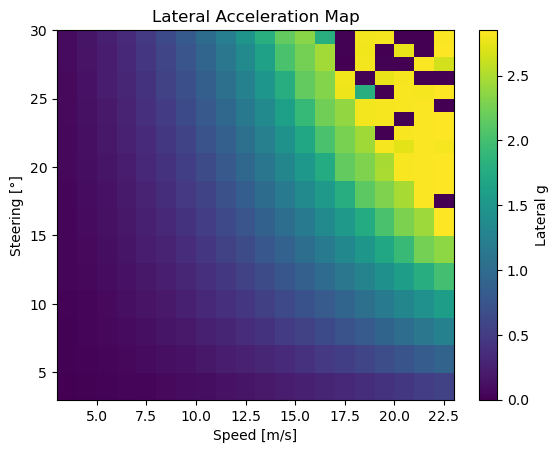

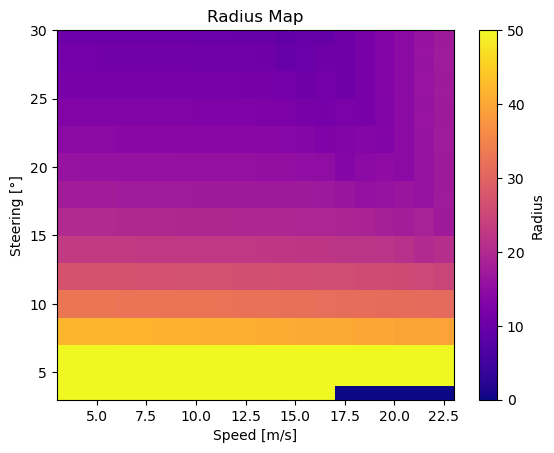

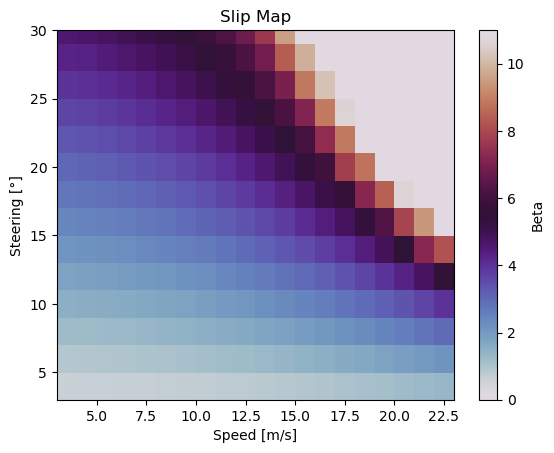

In [410]:
import matplotlib.pyplot as plt
Fyyy = np.clip(Fyyy, 0, 10)  # Replace negatives with 0
Ryyy = np.clip(Ryyy, 0, 50)
Byyy = np.clip(Byyy, 0, 11)


plt.imshow(Fyyy, extent=[3,23,3,30], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='Lateral g')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Lateral Acceleration Map')
plt.show()

plt.imshow(Ryyy, extent=[3,23,3,30], origin='lower', cmap='plasma', aspect='auto')
plt.colorbar(label='Radius')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Radius Map')
plt.show()

plt.imshow(Byyy, extent=[3,23,3,30], origin='lower', cmap='twilight', aspect='auto')
plt.colorbar(label='Beta')
plt.ylabel('Steering [°]')
plt.xlabel('Speed [m/s]')
plt.title('Slip Map')
plt.show()

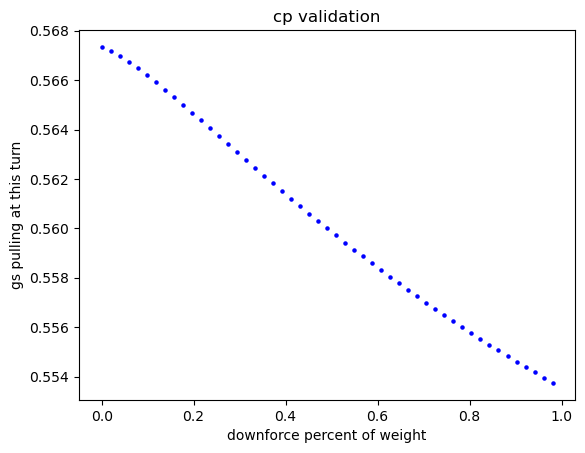

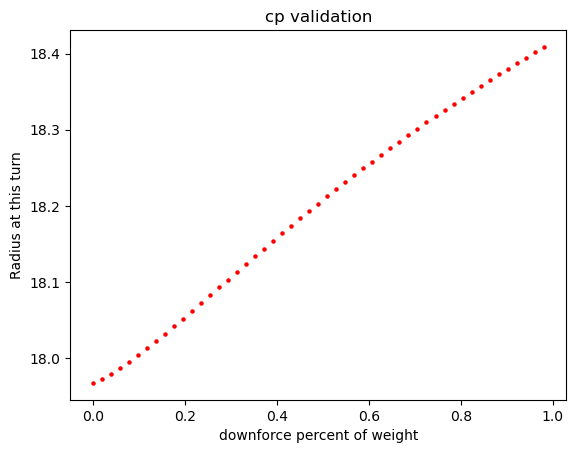

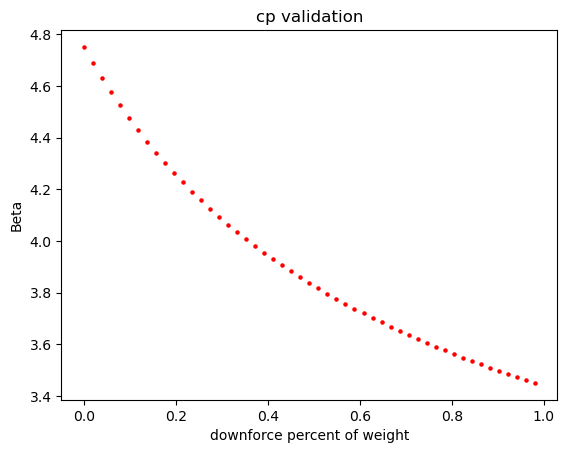

In [84]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for i in range(steps):
    ax.scatter(i/steps,gaero[i], s=5, color='blue')
plt.xlabel("downforce percent of weight")
plt.ylabel("gs pulling at this turn")
ax.set_title("cp validation")
plt.show()

fig, ax = plt.subplots()
for i in range(steps):
    ax.scatter(i/steps,Raero[i], s=5, color='red')
plt.xlabel("downforce percent of weight")
plt.ylabel("Radius at this turn")
ax.set_title("cp validation")
plt.show()

fig, ax = plt.subplots()
for i in range(steps):
    ax.scatter(i/steps,Baero[i]*180/np.pi, s=5, color='red')
plt.xlabel("downforce percent of weight")
plt.ylabel("Beta")
ax.set_title("cp validation")
plt.show()